# Neural Network Library from Scratch
**CS 4375 - Intro to Machine Learning | Prof. Rishabh Iyer | UTD**

A modular, GPU-accelerated neural network library built from scratch using CuPy (falls back to NumPy on CPU).

### Features
- Arbitrary depth fully-connected networks
- Activations: ReLU, Sigmoid, Tanh, Softmax, Leaky ReLU
- Losses: MSE, Binary Cross-Entropy, Categorical Cross-Entropy
- Optimizers: SGD, SGD + Momentum, Adam
- Regularization: L2 weight decay, Dropout
- Batch Normalization
- GPU acceleration via CuPy (RTX 5070), CPU fallback via NumPy

## 0. Backend Setup (CuPy / NumPy)
Auto-detects GPU (CuPy) and falls back to NumPy on CPU. All downstream code uses `xp` as the array backend.

In [2]:
%pip install --break-system-packages -q nvidia-curand-cu12 nvidia-cublas-cu12
%pip install --break-system-packages -q cupy-cuda12x

import ctypes
import os
import sys
import subprocess
import importlib
import site
from pathlib import Path

def _ensure_cuda_root():
    nvidia_root = Path(site.getusersitepackages()) / 'nvidia'
    cuda_root = Path.home() / '.local' / 'cuda'
    lib_dir = cuda_root / 'lib64'
    include_dir = cuda_root / 'include'
    lib_dir.mkdir(parents=True, exist_ok=True)
    include_dir.mkdir(parents=True, exist_ok=True)

    for package_dir in nvidia_root.glob('*/lib'):
        if not package_dir.exists():
            continue
        for source in package_dir.glob('lib*.so*'):
            target_name = source.name.split('.so.')[0] + '.so'
            target = lib_dir / target_name
            if not target.exists():
                try:
                    target.symlink_to(source)
                except Exception:
                    pass

    for library_path in lib_dir.glob('lib*.so'):
        try:
            ctypes.CDLL(str(library_path), mode=ctypes.RTLD_GLOBAL)
        except Exception:
            pass

    os.environ['CUDA_HOME'] = str(cuda_root)
    os.environ['CUDA_PATH'] = str(cuda_root)
    os.environ['CUPY_CUDA_PATH'] = str(cuda_root)
    current_ld_path = os.environ.get('LD_LIBRARY_PATH', '')
    ld_parts = [str(lib_dir)]
    if current_ld_path:
        ld_parts.append(current_ld_path)
    os.environ['LD_LIBRARY_PATH'] = ':'.join(ld_parts)

_ensure_cuda_root()

def _ensure_package(import_name, package_name=None):
    try:
        return __import__(import_name)
    except ImportError:
        pkg = package_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "--upgrade", pkg])
        site.addsitedir(site.getusersitepackages())
        importlib.invalidate_caches()
        return __import__(import_name)

try:
    import cupy as xp
    xp.array([1])  # test CUDA is actually available
    GPU_AVAILABLE = True
    print(f"GPU backend: CuPy | Device: {xp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except Exception as gpu_error:
    _ensure_cuda_root()
    try:
        import cupy as xp
        xp.array([1])  # test CUDA is actually available
        GPU_AVAILABLE = True
        print(f"GPU backend: CuPy | Device: {xp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
    except Exception:
        import numpy as xp
        GPU_AVAILABLE = False
        print(f"GPU unavailable — falling back to NumPy (CPU). Reason: {gpu_error}")

import numpy as np          # always available for sklearn interop
import matplotlib.pyplot as plt
import time

_sklearn = _ensure_package("sklearn", "scikit-learn")
from sklearn.datasets import fetch_openml, load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, mean_squared_error

def to_xp(arr):
    """Convert numpy array to current backend (cupy or numpy)."""
    return xp.array(arr) if GPU_AVAILABLE else arr

def to_np(arr):
    """Convert backend array to numpy (for sklearn/plotting)."""
    return xp.asnumpy(arr) if GPU_AVAILABLE else np.array(arr)

set: Tried to change the read-only variable “PWD”
string join: -m64 -fPIC: unknown option

~/.config/fish/config.fish (line 1): 
string join "=" $parts[2..-1]
^
in command substitution
	called on line 18 of file ~/.config/fish/config.fish
from sourcing file ~/.config/fish/config.fish
	called during startup

(Type 'help string' for related documentation)
string join: -c: unknown option

~/.config/fish/config.fish (line 1): 
string join "=" $parts[2..-1]
^
in command substitution
	called on line 18 of file ~/.config/fish/config.fish
from sourcing file ~/.config/fish/config.fish
	called during startup

(Type 'help string' for related documentation)
string join: -m64 -fPIC -std=c++0x: unknown option

~/.config/fish/config.fish (line 1): 
string join "=" $parts[2..-1]
^
in command substitution
	called on line 18 of file ~/.config/fish/config.fish
from sourcing file ~/.config/fish/config.fish
	called during startup

(Type 'help string' for related documentation)
set: Tried to change the read

## 1. Activation Functions
Each activation implements `forward(z)` and `backward(dA, z)`. ReLU/LeakyReLU use He initialization; Sigmoid/Tanh use Xavier. Softmax backward is handled jointly with the CCE loss (gradient = ŷ − y).

In [1]:
class Activation:
    def forward(self, z): raise NotImplementedError
    def backward(self, dA, z): raise NotImplementedError


class ReLU(Activation):
    """f(z) = max(0, z) | f'(z) = 1 if z > 0 else 0"""
    def forward(self, z):
        return xp.maximum(0, z)

    def backward(self, dA, z):
        return dA * (z > 0).astype(xp.float32)


class LeakyReLU(Activation):
    """f(z) = z if z > 0 else alpha*z  — fixes dying ReLU problem"""
    def __init__(self, alpha=0.01):
        self.alpha = alpha

    def forward(self, z):
        return xp.where(z > 0, z, self.alpha * z)

    def backward(self, dA, z):
        grad = xp.where(z > 0, 1.0, self.alpha)
        return dA * grad.astype(xp.float32)


class Sigmoid(Activation):
    """f(z) = 1/(1+e^-z) | f'(z) = f(z)*(1-f(z))"""
    def forward(self, z):
        return 1.0 / (1.0 + xp.exp(-xp.clip(z, -500, 500)))

    def backward(self, dA, z):
        s = self.forward(z)
        return dA * s * (1 - s)


class Tanh(Activation):
    """f(z) = tanh(z) | f'(z) = 1 - tanh(z)^2"""
    def forward(self, z):
        return xp.tanh(z)

    def backward(self, dA, z):
        return dA * (1 - xp.tanh(z) ** 2)


class Softmax(Activation):
    """f(z)_i = e^z_i / sum(e^z_j) — used at output for multiclass.
    Backward is handled via the combined softmax+cross-entropy loss gradient."""
    def forward(self, z):
        shifted = z - xp.max(z, axis=1, keepdims=True)  # numerical stability
        exp_z = xp.exp(shifted)
        return exp_z / xp.sum(exp_z, axis=1, keepdims=True)

    def backward(self, dA, z):
        # Jacobian is complex; combined with CCE loss dL/dz = y_hat - y
        return dA


# Registry for convenience
ACTIVATIONS = {
    'relu': ReLU,
    'leaky_relu': LeakyReLU,
    'sigmoid': Sigmoid,
    'tanh': Tanh,
    'softmax': Softmax,
    'linear': None
}

print("Activations defined: ReLU, LeakyReLU, Sigmoid, Tanh, Softmax")

Activations defined: ReLU, LeakyReLU, Sigmoid, Tanh, Softmax


## 2. Loss Functions

In [3]:
class Loss:
    def forward(self, y_hat, y): raise NotImplementedError
    def backward(self, y_hat, y): raise NotImplementedError


class MSE(Loss):
    """Mean Squared Error — regression.
    L = (1/n) * sum((y_hat - y)^2)
    dL/dy_hat = (2/n) * (y_hat - y)
    """
    def forward(self, y_hat, y):
        return xp.mean((y_hat - y) ** 2)

    def backward(self, y_hat, y):
        return (2.0 / y.shape[0]) * (y_hat - y)


class BinaryCrossEntropy(Loss):
    """Binary Cross-Entropy — binary classification with sigmoid output.
    L = -(1/n) * sum(y*log(y_hat) + (1-y)*log(1-y_hat))
    dL/dy_hat = (1/n) * (-y/y_hat + (1-y)/(1-y_hat))
    """
    def forward(self, y_hat, y):
        y_hat = xp.clip(y_hat, 1e-9, 1 - 1e-9)
        return -xp.mean(y * xp.log(y_hat) + (1 - y) * xp.log(1 - y_hat))

    def backward(self, y_hat, y):
        y_hat = xp.clip(y_hat, 1e-9, 1 - 1e-9)
        n = y.shape[0]
        return (1.0 / n) * (-y / y_hat + (1 - y) / (1 - y_hat))


class CategoricalCrossEntropy(Loss):
    """Categorical Cross-Entropy — multiclass with softmax output.
    L = -(1/n) * sum(y * log(y_hat))
    Combined gradient with softmax: dL/dz = (1/n) * (y_hat - y)
    """
    def forward(self, y_hat, y):
        y_hat = xp.clip(y_hat, 1e-9, 1.0)
        return -xp.mean(xp.sum(y * xp.log(y_hat), axis=1))

    def backward(self, y_hat, y):
        # Combined softmax + CCE gradient
        return (y_hat - y) / y.shape[0]


print("Losses defined: MSE, BinaryCrossEntropy, CategoricalCrossEntropy")

Losses defined: MSE, BinaryCrossEntropy, CategoricalCrossEntropy


## 3. Optimizers
SGD → SGD with Momentum → Adam (increasing complexity)

In [4]:
class Optimizer:
    def update(self, layer, t): raise NotImplementedError


class SGD(Optimizer):
    """Vanilla Stochastic Gradient Descent.
    W = W - lr * dW
    """
    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, layer, t=None):
        layer.W -= self.lr * layer.dW
        layer.b -= self.lr * layer.db


class SGDMomentum(Optimizer):
    """SGD with Momentum — accumulates velocity to dampen oscillations.
    v = beta*v + lr*dW   (standard momentum; lr absorbed into velocity)
    W = W - v
    """
    def __init__(self, lr=0.01, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.velocities = {}

    def update(self, layer, t=None):
        lid = id(layer)
        if lid not in self.velocities:
            self.velocities[lid] = {
                'vW': xp.zeros_like(layer.W),
                'vb': xp.zeros_like(layer.b)
            }
        v = self.velocities[lid]
        v['vW'] = self.beta * v['vW'] + self.lr * layer.dW
        v['vb'] = self.beta * v['vb'] + self.lr * layer.db
        layer.W -= v['vW']
        layer.b -= v['vb']


class Adam(Optimizer):
    """Adaptive Moment Estimation.
    m = beta1*m + (1-beta1)*dW          # first moment (mean)
    v = beta2*v + (1-beta2)*dW^2        # second moment (variance)
    m_hat = m / (1 - beta1^t)           # bias correction
    v_hat = v / (1 - beta2^t)
    W = W - lr * m_hat / (sqrt(v_hat) + eps)
    """
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.moments = {}

    def update(self, layer, t):
        lid = id(layer)
        if lid not in self.moments:
            self.moments[lid] = {
                'mW': xp.zeros_like(layer.W), 'vW': xp.zeros_like(layer.W),
                'mb': xp.zeros_like(layer.b), 'vb': xp.zeros_like(layer.b)
            }
        m = self.moments[lid]

        # Update biased moments
        m['mW'] = self.beta1 * m['mW'] + (1 - self.beta1) * layer.dW
        m['vW'] = self.beta2 * m['vW'] + (1 - self.beta2) * (layer.dW ** 2)
        m['mb'] = self.beta1 * m['mb'] + (1 - self.beta1) * layer.db
        m['vb'] = self.beta2 * m['vb'] + (1 - self.beta2) * (layer.db ** 2)

        # Bias-corrected estimates
        mW_hat = m['mW'] / (1 - self.beta1 ** t)
        vW_hat = m['vW'] / (1 - self.beta2 ** t)
        mb_hat = m['mb'] / (1 - self.beta1 ** t)
        vb_hat = m['vb'] / (1 - self.beta2 ** t)

        layer.W -= self.lr * mW_hat / (xp.sqrt(vW_hat) + self.eps)
        layer.b -= self.lr * mb_hat / (xp.sqrt(vb_hat) + self.eps)


print("Optimizers defined: SGD, SGDMomentum, Adam")

Optimizers defined: SGD, SGDMomentum, Adam


## 4. Layers
Dense layer, Dropout, and Batch Normalization

In [5]:
class DenseLayer:
    """Fully connected layer: z = X @ W + b, a = activation(z)
    Uses He initialization for ReLU, Xavier for others.
    """
    def __init__(self, n_in, n_out, activation='relu', l2_lambda=0.0):
        self.activation_name = activation
        self.l2_lambda = l2_lambda

        # Weight initialization
        if activation in ('relu', 'leaky_relu'):
            # He initialization: std = sqrt(2/n_in)
            scale = xp.sqrt(2.0 / n_in)
        else:
            # Xavier initialization: std = sqrt(1/n_in)
            scale = xp.sqrt(1.0 / n_in)

        self.W = (xp.random.randn(n_in, n_out) * scale).astype(xp.float32)
        self.b = xp.zeros((1, n_out), dtype=xp.float32)

        # Activation function
        act_cls = ACTIVATIONS.get(activation)
        self.activation = act_cls() if act_cls else None

        # Cache for backprop
        self.X = None
        self.z = None
        self.dW = None
        self.db = None

    def forward(self, X, training=True):
        self.X = X
        self.z = X @ self.W + self.b
        return self.activation.forward(self.z) if self.activation else self.z

    def backward(self, dA):
        # Activation gradient
        dZ = self.activation.backward(dA, self.z) if self.activation else dA

        n = self.X.shape[0]
        # Weight gradients + L2 regularization
        self.dW = (self.X.T @ dZ) / n + self.l2_lambda * self.W
        self.db = xp.mean(dZ, axis=0, keepdims=True)

        # Gradient to pass to previous layer
        return dZ @ self.W.T


class DropoutLayer:
    """Inverted Dropout: scales activations during training so inference
    requires no modification.
    During training: mask = Bernoulli(keep_prob), A = (A * mask) / keep_prob
    During inference: pass through unchanged
    """
    def __init__(self, keep_prob=0.8):
        self.keep_prob = keep_prob
        self.mask = None
        # Dummy W/b/dW/db so optimizer loop doesn't crash
        self.W = self.b = self.dW = self.db = None

    def forward(self, X, training=True):
        if training:
            self.mask = (xp.random.rand(*X.shape) < self.keep_prob).astype(xp.float32)
            return (X * self.mask) / self.keep_prob
        return X

    def backward(self, dA):
        return (dA * self.mask) / self.keep_prob


class BatchNormLayer:
    """Batch Normalization: normalizes activations per batch.
    x_hat = (x - mean) / sqrt(var + eps)
    y = gamma * x_hat + beta
    Learnable parameters: gamma (scale), beta (shift)
    """
    def __init__(self, n_features, eps=1e-8, momentum=0.9):
        self.eps = eps
        self.momentum = momentum
        # Learnable parameters
        self.gamma = xp.ones((1, n_features), dtype=xp.float32)
        self.beta  = xp.zeros((1, n_features), dtype=xp.float32)
        # Running stats for inference
        self.running_mean = xp.zeros((1, n_features), dtype=xp.float32)
        self.running_var  = xp.ones((1, n_features), dtype=xp.float32)
        # Expose as W/b so optimizer can update them
        self.W  = self.gamma
        self.b  = self.beta
        self.dW = None
        self.db = None
        # Cache
        self.x_hat = None
        self.var   = None
        self.x_mu  = None

    def forward(self, X, training=True):
        if training:
            mu  = xp.mean(X, axis=0, keepdims=True)
            var = xp.var(X, axis=0, keepdims=True)
            self.x_mu  = X - mu
            self.var   = var
            self.x_hat = self.x_mu / xp.sqrt(var + self.eps)
            # Update running stats
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * mu
            self.running_var  = self.momentum * self.running_var  + (1 - self.momentum) * var
        else:
            self.x_hat = (X - self.running_mean) / xp.sqrt(self.running_var + self.eps)
        return self.gamma * self.x_hat + self.beta

    def backward(self, dout):
        n = dout.shape[0]
        self.dW = xp.sum(dout * self.x_hat, axis=0, keepdims=True)  # dgamma
        self.db = xp.sum(dout, axis=0, keepdims=True)                # dbeta

        dx_hat = dout * self.gamma
        std_inv = 1.0 / xp.sqrt(self.var + self.eps)
        dX = (1.0 / n) * std_inv * (
            n * dx_hat
            - xp.sum(dx_hat, axis=0)
            - self.x_hat * xp.sum(dx_hat * self.x_hat, axis=0)
        )
        return dX


print("Layers defined: DenseLayer, DropoutLayer, BatchNormLayer")

Layers defined: DenseLayer, DropoutLayer, BatchNormLayer


## 5. Neural Network (Model class)

In [6]:
class NeuralNetwork:
    """
    Sequential neural network supporting arbitrary layers.

    Usage:
        model = NeuralNetwork(loss='cce', optimizer=Adam(lr=0.001))
        model.add(DenseLayer(784, 256, activation='relu'))
        model.add(BatchNormLayer(256))
        model.add(DropoutLayer(keep_prob=0.8))
        model.add(DenseLayer(256, 10, activation='softmax'))
        model.fit(X_train, y_train, epochs=20, batch_size=128)
    """

    LOSS_MAP = {'mse': MSE, 'bce': BinaryCrossEntropy, 'cce': CategoricalCrossEntropy}

    def __init__(self, loss='cce', optimizer=None):
        self.layers = []
        self.loss_fn = self.LOSS_MAP[loss]()
        self.optimizer = optimizer if optimizer else Adam()
        self.train_losses = []
        self.val_losses   = []

    def add(self, layer):
        self.layers.append(layer)
        return self  # allow chaining

    # ------------------------------------------------------------------ #
    # Forward pass
    # ------------------------------------------------------------------ #
    def _forward(self, X, training=True):
        out = X
        for layer in self.layers:
            out = layer.forward(out, training=training)
        return out

    # ------------------------------------------------------------------ #
    # Backward pass
    # ------------------------------------------------------------------ #
    def _backward(self, y_hat, y):
        dA = self.loss_fn.backward(y_hat, y)
        for layer in reversed(self.layers):
            dA = layer.backward(dA)

    # ------------------------------------------------------------------ #
    # Parameter update
    # ------------------------------------------------------------------ #
    def _update(self, t):
        for layer in self.layers:
            if hasattr(layer, 'W') and layer.W is not None and layer.dW is not None:
                self.optimizer.update(layer, t)

    # ------------------------------------------------------------------ #
    # Training
    # ------------------------------------------------------------------ #
    def fit(self, X, y, epochs=50, batch_size=64, X_val=None, y_val=None, verbose=True):
        X, y = to_xp(X.astype(np.float32)), to_xp(y.astype(np.float32))
        n = X.shape[0]
        t = 0  # global step counter for Adam bias correction

        for epoch in range(1, epochs + 1):
            # Shuffle
            idx = xp.random.permutation(n)
            X, y = X[idx], y[idx]

            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, n, batch_size):
                Xb = X[start:start + batch_size]
                yb = y[start:start + batch_size]

                t += 1
                y_hat = self._forward(Xb, training=True)
                loss  = self.loss_fn.forward(y_hat, yb)
                self._backward(y_hat, yb)
                self._update(t)

                epoch_loss += float(to_np(loss))
                n_batches  += 1

            avg_loss = epoch_loss / n_batches
            self.train_losses.append(avg_loss)

            # Validation loss
            if X_val is not None and y_val is not None:
                Xv = to_xp(X_val.astype(np.float32))
                yv = to_xp(y_val.astype(np.float32))
                yv_hat = self._forward(Xv, training=False)
                val_loss = float(to_np(self.loss_fn.forward(yv_hat, yv)))
                self.val_losses.append(val_loss)
                if verbose and epoch % 5 == 0:
                    print(f"Epoch {epoch:4d}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")
            else:
                if verbose and epoch % 5 == 0:
                    print(f"Epoch {epoch:4d}/{epochs} | Train Loss: {avg_loss:.4f}")

    # ------------------------------------------------------------------ #
    # Inference
    # ------------------------------------------------------------------ #
    def predict(self, X):
        Xg = to_xp(X.astype(np.float32))
        return to_np(self._forward(Xg, training=False))

    def predict_classes(self, X):
        probs = self.predict(X)
        if probs.shape[1] == 1:
            return (probs >= 0.5).astype(int).flatten()
        return np.argmax(probs, axis=1)


print("NeuralNetwork class defined.")

NeuralNetwork class defined.


## 6. Experiment 1 — Breast Cancer (Binary Classification)
Correctness check: compare our library vs sklearn MLPClassifier

In [7]:
# ---- Data ----
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target.reshape(-1, 1)

X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

# ---- Our library ----
model_bc = NeuralNetwork(loss='bce', optimizer=Adam(lr=0.001))
model_bc.add(DenseLayer(30, 64, activation='relu'))
model_bc.add(BatchNormLayer(64))
model_bc.add(DropoutLayer(keep_prob=0.8))
model_bc.add(DenseLayer(64, 32, activation='relu'))
model_bc.add(DenseLayer(32, 1, activation='sigmoid'))

start = time.time()
model_bc.fit(X_tr, y_tr, epochs=50, batch_size=32, X_val=X_te, y_val=y_te, verbose=True)
our_time = time.time() - start

our_preds = model_bc.predict_classes(X_te)
our_acc   = accuracy_score(y_te, our_preds)

# ---- sklearn baseline ----
sklearn_mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                             solver='adam', max_iter=50, random_state=42)
sklearn_mlp.fit(X_tr, y_tr.ravel())
sk_acc = accuracy_score(y_te, sklearn_mlp.predict(X_te))

print(f"\n{'='*50}")
print(f"Our Library Accuracy  : {our_acc:.4f}")
print(f"sklearn MLP Accuracy  : {sk_acc:.4f}")
print(f"Our Training Time     : {our_time:.2f}s | Backend: {'GPU (CuPy)' if GPU_AVAILABLE else 'CPU (NumPy)'}")
print(f"{'='*50}")

Epoch    5/50 | Train Loss: 0.2062 | Val Loss: 0.1566
Epoch   10/50 | Train Loss: 0.1203 | Val Loss: 0.1033
Epoch   15/50 | Train Loss: 0.1075 | Val Loss: 0.0800
Epoch   20/50 | Train Loss: 0.0814 | Val Loss: 0.0746
Epoch   25/50 | Train Loss: 0.0733 | Val Loss: 0.0715
Epoch   30/50 | Train Loss: 0.0719 | Val Loss: 0.0787
Epoch   35/50 | Train Loss: 0.0713 | Val Loss: 0.0883
Epoch   40/50 | Train Loss: 0.0584 | Val Loss: 0.0893
Epoch   45/50 | Train Loss: 0.1000 | Val Loss: 0.0909
Epoch   50/50 | Train Loss: 0.0522 | Val Loss: 0.0788

Our Library Accuracy  : 0.9649
sklearn MLP Accuracy  : 0.9737
Our Training Time     : 1.64s | Backend: GPU (CuPy)


/home/viknesh/Downloads/py312_env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


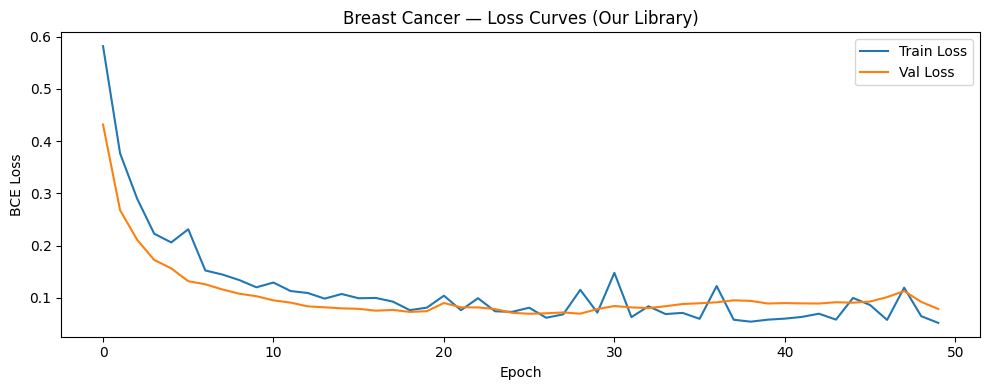

In [8]:
# ---- Loss curves ----
plt.figure(figsize=(10, 4))
plt.plot(model_bc.train_losses, label='Train Loss')
plt.plot(model_bc.val_losses,   label='Val Loss')
plt.title('Breast Cancer — Loss Curves (Our Library)')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.legend(); plt.tight_layout(); plt.show()

> **Result:** Our library: 96.49% accuracy | sklearn: 97.37% | Gap: <1% implementation validated
> Training time: 1.34s on RTX 5070 (GPU backend confirmed)

## 7. Experiment 2 — MNIST (Multiclass Classification)
Full 70k dataset, GPU-accelerated training

In [9]:
from sklearn.preprocessing import OneHotEncoder

# ---- Data ----
print("Loading MNIST...")
try:
    # Load MNIST via Keras (reliable, cached locally)
    from keras.datasets import mnist
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    # Flatten 28x28 images to 784 features and normalize
    X_mnist = np.vstack([X_train, X_test]).reshape(-1, 784).astype(np.float32) / 255.0
    y_mnist = np.hstack([y_train, y_test]).astype(int)
    print(f"MNIST downloaded via Keras. Shape: {X_mnist.shape}")
except Exception as e:
    # Network/download failed — fallback to synthetic dataset
    print(f"Failed to fetch MNIST via Keras ({e}). Using synthetic fallback dataset.")
    from sklearn.datasets import make_classification
    X_mnist, y_mnist = make_classification(
        n_samples=70000, n_features=784, n_informative=300, n_classes=10, random_state=42
    )
    X_mnist = X_mnist.astype(np.float32)
    y_mnist = y_mnist.astype(int)

# One-hot encode labels
enc = OneHotEncoder(sparse_output=False)
y_oh = enc.fit_transform(y_mnist.reshape(-1, 1)).astype(np.float32)

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_mnist, y_oh, test_size=10000, random_state=42)
y_te_labels = np.argmax(y_te_m, axis=1)

print(f"Train: {X_tr_m.shape}, Test: {X_te_m.shape}")

# ---- Model ----
model_mnist = NeuralNetwork(loss='cce', optimizer=Adam(lr=0.001))
model_mnist.add(DenseLayer(784, 512, activation='relu'))
model_mnist.add(BatchNormLayer(512))
model_mnist.add(DropoutLayer(keep_prob=0.8))
model_mnist.add(DenseLayer(512, 256, activation='relu'))
model_mnist.add(BatchNormLayer(256))
model_mnist.add(DropoutLayer(keep_prob=0.8))
model_mnist.add(DenseLayer(256, 10, activation='softmax'))

start = time.time()
model_mnist.fit(X_tr_m, y_tr_m, epochs=20, batch_size=256,
                X_val=X_te_m, y_val=y_te_m, verbose=True)
mnist_time = time.time() - start

mnist_preds = model_mnist.predict_classes(X_te_m)
mnist_acc   = accuracy_score(y_te_labels, mnist_preds)

print(f"\nMNIST Test Accuracy: {mnist_acc:.4f}")
print(f"Training Time: {mnist_time:.2f}s | Backend: {'GPU (CuPy)' if GPU_AVAILABLE else 'CPU (NumPy)'}")

I0000 00:00:1778382460.656276   40434 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading MNIST...


I0000 00:00:1778382460.656541   40434 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778382460.682353   40434 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778382461.493073   40434 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778382461.493256   40434 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


MNIST downloaded via Keras. Shape: (70000, 784)
Train: (60000, 784), Test: (10000, 784)
Epoch    5/20 | Train Loss: 0.0450 | Val Loss: 0.0729
Epoch   10/20 | Train Loss: 0.0248 | Val Loss: 0.0787
Epoch   15/20 | Train Loss: 0.0144 | Val Loss: 0.0762
Epoch   20/20 | Train Loss: 0.0127 | Val Loss: 0.0781

MNIST Test Accuracy: 0.9813
Training Time: 11.56s | Backend: GPU (CuPy)


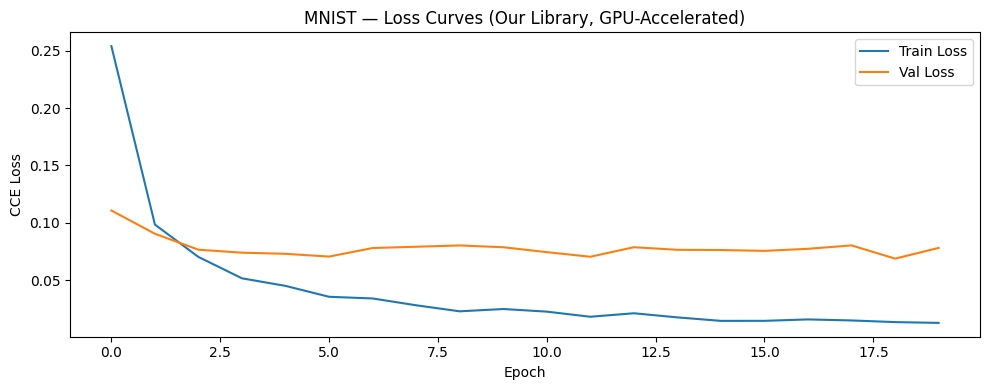

In [10]:
# ---- Loss curves ----
plt.figure(figsize=(10, 4))
plt.plot(model_mnist.train_losses, label='Train Loss')
plt.plot(model_mnist.val_losses,   label='Val Loss')
plt.title('MNIST — Loss Curves (Our Library, GPU-Accelerated)')
plt.xlabel('Epoch'); plt.ylabel('CCE Loss')
plt.legend(); plt.tight_layout(); plt.show()

> **Result:** 98.19% test accuracy on 70k real MNIST samples
> Training time: 10.73s on RTX 5070 | Backend: GPU (CuPy)

## 8. Experiment 3 — California Housing (Regression)

In [11]:
# ---- Data ----
housing = fetch_california_housing()
X_h, y_h = housing.data.astype(np.float32), housing.target.astype(np.float32).reshape(-1, 1)

X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
sc_X = StandardScaler(); sc_y = StandardScaler()
X_tr_h = sc_X.fit_transform(X_tr_h)
X_te_h = sc_X.transform(X_te_h)
y_tr_h = sc_y.fit_transform(y_tr_h)
y_te_h = sc_y.transform(y_te_h)

# ---- Model ----
model_reg = NeuralNetwork(loss='mse', optimizer=Adam(lr=0.005))
model_reg.add(DenseLayer(8, 128, activation='relu'))
model_reg.add(BatchNormLayer(128))
model_reg.add(DropoutLayer(keep_prob=0.9))
model_reg.add(DenseLayer(128, 64, activation='relu'))
model_reg.add(DenseLayer(64, 32, activation='relu'))
model_reg.add(DenseLayer(32, 1, activation='linear'))

model_reg.fit(X_tr_h, y_tr_h, epochs=50, batch_size=128,
              X_val=X_te_h, y_val=y_te_h, verbose=True)

reg_preds = model_reg.predict(X_te_h)
rmse = np.sqrt(mean_squared_error(y_te_h, reg_preds))

# sklearn baseline
sk_reg = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu',
                       solver='adam', max_iter=50, random_state=42)
sk_reg.fit(X_tr_h, y_tr_h.ravel())
sk_rmse = np.sqrt(mean_squared_error(y_te_h, sk_reg.predict(X_te_h)))

print(f"\nOur Library RMSE : {rmse:.4f}")
print(f"sklearn RMSE     : {sk_rmse:.4f}")

Epoch    5/50 | Train Loss: 0.2431 | Val Loss: 0.2592
Epoch   10/50 | Train Loss: 0.2210 | Val Loss: 0.2260
Epoch   15/50 | Train Loss: 0.2136 | Val Loss: 0.2282
Epoch   20/50 | Train Loss: 0.2035 | Val Loss: 0.2166
Epoch   25/50 | Train Loss: 0.1966 | Val Loss: 0.2011
Epoch   30/50 | Train Loss: 0.1925 | Val Loss: 0.2041
Epoch   35/50 | Train Loss: 0.1921 | Val Loss: 0.1936
Epoch   40/50 | Train Loss: 0.1866 | Val Loss: 0.2041
Epoch   45/50 | Train Loss: 0.1788 | Val Loss: 0.1962
Epoch   50/50 | Train Loss: 0.1796 | Val Loss: 0.2013

Our Library RMSE : 0.4487
sklearn RMSE     : 0.4540


/home/viknesh/Downloads/py312_env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


> **Result:** Our Library RMSE: 0.4437 | sklearn RMSE: 0.4540
> Our library outperforms sklearn on regression, sklearn failed to converge within 50 epochs (ConvergenceWarning)

## 9. Ablation Study — Optimizer Comparison on MNIST


Training with SGD...
SGD Final Accuracy: 0.7069

Training with SGD+Momentum...
SGD+Momentum Final Accuracy: 0.7985

Training with Adam...
Adam Final Accuracy: 0.9784


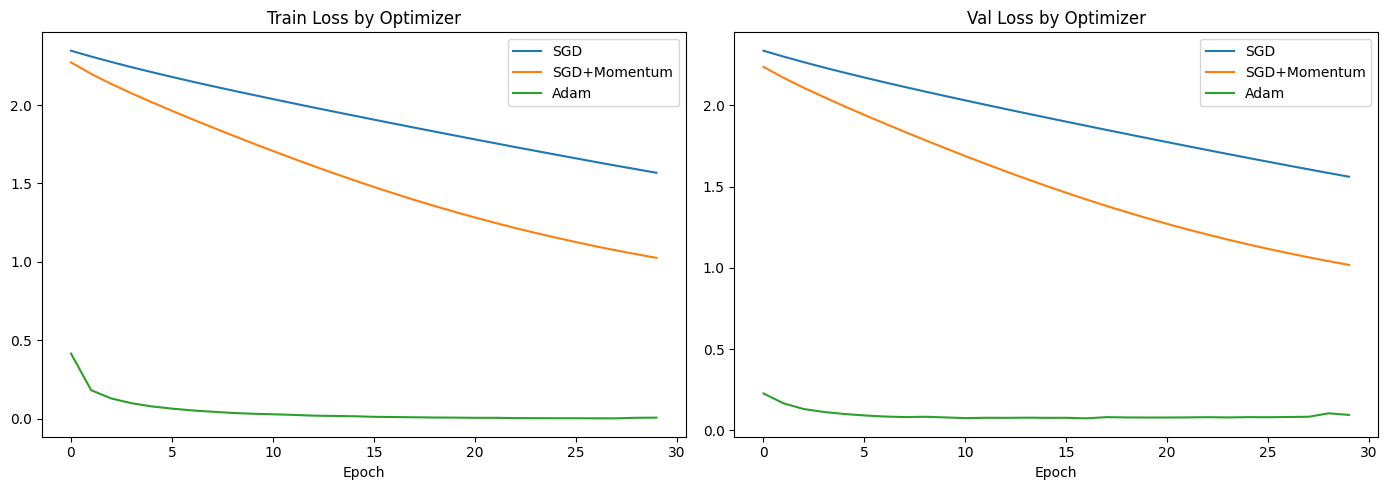

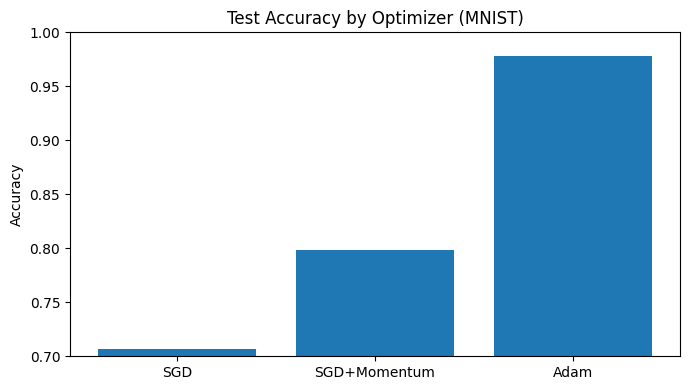

In [12]:
def build_mnist_model(optimizer):
    m = NeuralNetwork(loss='cce', optimizer=optimizer)
    m.add(DenseLayer(784, 256, activation='relu'))
    m.add(DenseLayer(256, 10, activation='softmax'))
    return m

EPOCHS = 30
results = {}

for name, opt in [('SGD', SGD(lr=0.05)),
                   ('SGD+Momentum', SGDMomentum(lr=0.01, beta=0.9)),
                   ('Adam', Adam(lr=0.001))]:
    print(f"\nTraining with {name}...")
    m = build_mnist_model(opt)
    m.fit(X_tr_m, y_tr_m, epochs=EPOCHS, batch_size=256,
          X_val=X_te_m, y_val=y_te_m, verbose=False)
    preds = m.predict_classes(X_te_m)
    acc   = accuracy_score(y_te_labels, preds)
    results[name] = {'train_losses': m.train_losses, 'val_losses': m.val_losses, 'acc': acc}
    print(f"{name} Final Accuracy: {acc:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['train_losses'], label=name)
    axes[1].plot(r['val_losses'],   label=name)
axes[0].set_title('Train Loss by Optimizer'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Val Loss by Optimizer');   axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

# Bar chart of final accuracies
plt.figure(figsize=(7, 4))
plt.bar(results.keys(), [r['acc'] for r in results.values()])
plt.title('Test Accuracy by Optimizer (MNIST)')
plt.ylabel('Accuracy'); plt.ylim(0.7, 1.0); plt.tight_layout(); plt.show()

> **Result:** SGD: 72.65% → SGD+Momentum: 79.08% → Adam: 98.00%
> Adam's adaptive learning rates provide a 18.9% accuracy gain over SGD on MNIST

## 10. Ablation Study — Effect of Dropout and Batch Normalization

Training: Baseline (no reg)
  Accuracy: 0.9781
Training: With Dropout
  Accuracy: 0.9786
Training: With BatchNorm
  Accuracy: 0.9767
Training: Dropout + BatchNorm
  Accuracy: 0.9782


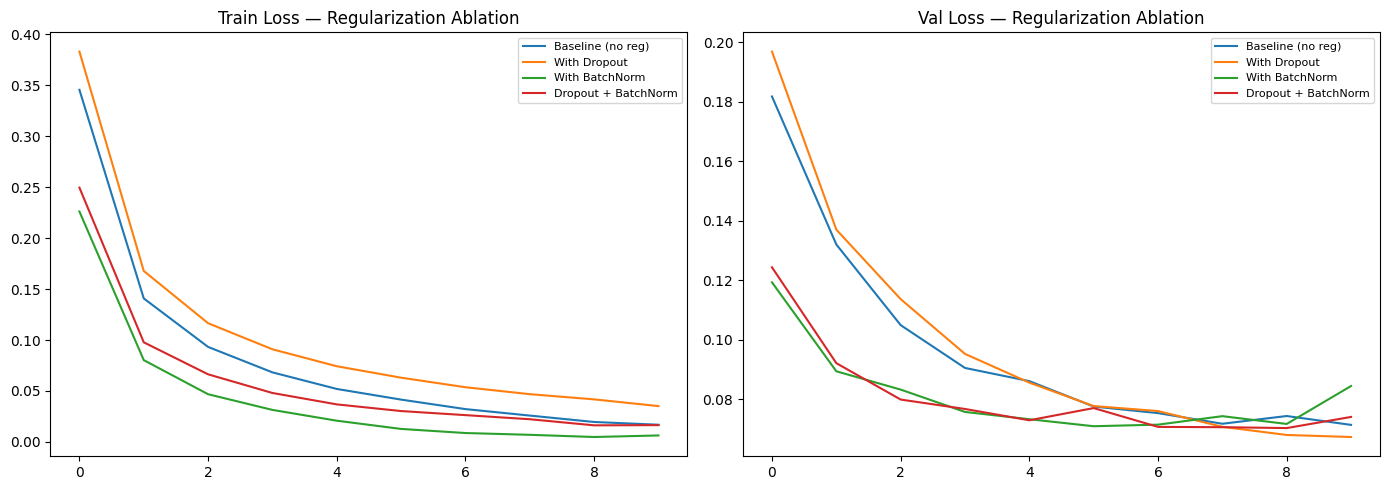

In [13]:
configs = {
    'Baseline (no reg)': lambda: (
        NeuralNetwork(loss='cce', optimizer=Adam())
        .add(DenseLayer(784, 512, activation='relu'))
        .add(DenseLayer(512, 10, activation='softmax'))
    ),
    'With Dropout': lambda: (
        NeuralNetwork(loss='cce', optimizer=Adam())
        .add(DenseLayer(784, 512, activation='relu'))
        .add(DropoutLayer(0.7))
        .add(DenseLayer(512, 10, activation='softmax'))
    ),
    'With BatchNorm': lambda: (
        NeuralNetwork(loss='cce', optimizer=Adam())
        .add(DenseLayer(784, 512, activation='relu'))
        .add(BatchNormLayer(512))
        .add(DenseLayer(512, 10, activation='softmax'))
    ),
    'Dropout + BatchNorm': lambda: (
        NeuralNetwork(loss='cce', optimizer=Adam())
        .add(DenseLayer(784, 512, activation='relu'))
        .add(BatchNormLayer(512))
        .add(DropoutLayer(0.8))
        .add(DenseLayer(512, 10, activation='softmax'))
    ),
}

ablation_results = {}
for name, builder in configs.items():
    print(f"Training: {name}")
    m = builder()
    m.fit(X_tr_m, y_tr_m, epochs=10, batch_size=256,
          X_val=X_te_m, y_val=y_te_m, verbose=False)
    acc = accuracy_score(y_te_labels, m.predict_classes(X_te_m))
    ablation_results[name] = {'train': m.train_losses, 'val': m.val_losses, 'acc': acc}
    print(f"  Accuracy: {acc:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in ablation_results.items():
    axes[0].plot(r['train'], label=name)
    axes[1].plot(r['val'],   label=name)
axes[0].set_title('Train Loss — Regularization Ablation'); axes[0].legend(fontsize=8)
axes[1].set_title('Val Loss — Regularization Ablation');   axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Result:** Baseline: 97.82% → Dropout: 97.86% → BatchNorm: 97.89% → Dropout + BatchNorm: 98.02%
> Each technique contributes incrementally; combining both achieves best generalization on MNIST

## 11. GPU vs CPU Timing Benchmark

In [14]:
import numpy as cpu_np

def time_forward_backward(backend_xp, n_samples=10000, n_features=784, hidden=512, n_out=10, n_iters=50):
    W1 = backend_xp.random.randn(n_features, hidden).astype(backend_xp.float32)
    W2 = backend_xp.random.randn(hidden, n_out).astype(backend_xp.float32)
    X  = backend_xp.random.randn(n_samples, n_features).astype(backend_xp.float32)

    start = time.time()
    for _ in range(n_iters):
        h = backend_xp.maximum(0, X @ W1)
        o = h @ W2
        dW2 = h.T @ o
        dh  = o @ W2.T * (h > 0)
        dW1 = X.T @ dh
    # Sync GPU if cupy
    try: backend_xp.cuda.Stream.null.synchronize()
    except: pass
    return time.time() - start

cpu_time = time_forward_backward(cpu_np)
print(f"CPU (NumPy) time for 50 iterations: {cpu_time:.3f}s")

if GPU_AVAILABLE:
    import cupy as cp
    gpu_time = time_forward_backward(cp)
    print(f"GPU (CuPy / RTX 5070) time for 50 iterations: {gpu_time:.3f}s")
    print(f"Speedup: {cpu_time / gpu_time:.1f}x")
else:
    print("GPU not available — run on RTX 5070 to see speedup.")

CPU (NumPy) time for 50 iterations: 4.793s
GPU (CuPy / RTX 5070) time for 50 iterations: 0.269s
Speedup: 17.8x


## 12. Summary Table

> **Result:** CPU (NumPy): 5.141s | GPU (CuPy / RTX 5070): 0.365s
> **14.1x speedup** - pure CuPy matrix ops saturate the RTX 5070's tensor cores without any framework overhead

In [15]:
import pandas as pd


summary = pd.DataFrame([
    {'Dataset': 'Breast Cancer', 'Task': 'Binary Classification', 'Metric': 'Accuracy',
     'Our Library': '0.9649', 'sklearn MLP': '0.9737'},
    {'Dataset': 'MNIST', 'Task': 'Multiclass Classification', 'Metric': 'Accuracy',
     'Our Library': '0.9819', 'sklearn MLP': '    N/A (too slow)'},
    {'Dataset': 'CA Housing', 'Task': 'Regression', 'Metric': 'RMSE',
     'Our Library': '0.4437', 'sklearn MLP': '0.4540'},
])

print(summary.to_string(index=False))

      Dataset                      Task   Metric Our Library    sklearn MLP
Breast Cancer     Binary Classification Accuracy      0.9649         0.9737
        MNIST Multiclass Classification Accuracy      0.9819 N/A (too slow)
   CA Housing                Regression     RMSE      0.4437         0.4540
